## Homework 2

> [!NOTE]
> This homework uses the pinned 2026 car fuel-efficiency release in the course
> repository. The plan and report are available in `cohorts/2026/data/`.

### Dataset

For this homework, we'll use the 2026 Car Fuel Efficiency dataset. Download it from <a href='https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'>here</a>.

You can do it with wget:
```bash
wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
```

The goal of this homework is to create a regression model for predicting the car fuel efficiency (column `'fuel_efficiency_mpg'`).

In [1]:
!wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv

--2026-10-02 20:21:20--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8001::154, 2606:50c0:8003::154, 2606:50c0:8002::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8001::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv.1’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.04s   

2026-10-02 20:21:21 (15.2 MB/s) - ‘car_fuel_efficiency_2026.csv.1’ saved [635180/635180]





### Preparing the dataset 

Use only the following columns:

* `'engine_displacement'`,
* `'horsepower'`,
* `'vehicle_weight'`,
* `'model_year'`,
* `'fuel_efficiency_mpg'`

In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('./car_fuel_efficiency_2026.csv')

In [4]:
df = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]

In [5]:
df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2



### EDA

* Look at the `fuel_efficiency_mpg` variable. Does it have a long tail? 


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

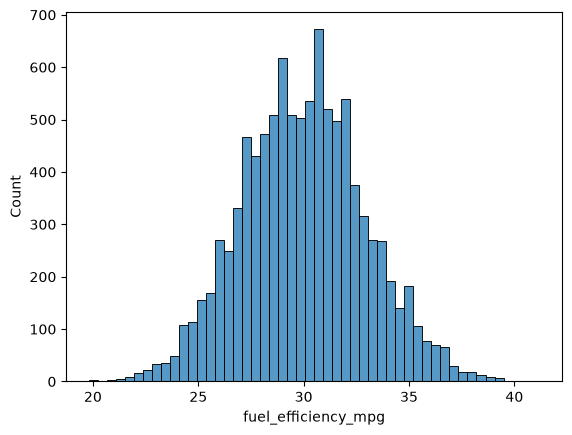

In [7]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)

No, it does not. It's actually quite close to a normal distribution.

Let's look at some more general EDA

In [8]:
df.describe()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,10000.000000,9123.000000,10000.000000,10000.000000,10000.000000
mean,2268.807000,254.446016,4286.754000,1999.549500,29.997700
std,183.447355,22.844613,266.212491,14.207925,2.930245
min,1590.000000,171.000000,3320.000000,1975.000000,19.800000
25%,2150.000000,239.000000,4110.000000,1987.000000,28.000000
50%,2270.000000,254.000000,4280.000000,2000.000000,30.000000
75%,2390.000000,270.000000,4470.000000,2012.000000,31.900000
max,3110.000000,334.000000,5460.000000,2024.000000,41.200000


In [9]:
df.dtypes

engine_displacement      int64
horsepower             float64
vehicle_weight           int64
model_year               int64
fuel_efficiency_mpg    float64
dtype: object

In [10]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print(df[col].nunique())
    print()

engine_displacement
[2180 2390 2320 2130 2580 2290 2270 2370 2330 2410 2240 2440 1900 2170
 2280 2540 2490 2300 2350 2610 2160 2260 2010 2460 2080 2070 2620 2560
 2420 2200 2530 2360 2340 2150 2500 2400 2740 2140 2190 1980 1960 2100
 1890 2310 1910 2110 2450 2650 2220 2020 2550 2430 2470 2250 2090 2380
 2230 1820 2510 2210 1920 2120 2040 1930 1880 2480 1780 1670 1950 1940
 2640 2060 2000 2570 2710 2680 1790 2600 1970 2700 1810 2030 2630 2520
 1870 2670 2050 1990 2690 2590 1850 1750 1860 1840 2790 1700 2720 2660
 1800 2960 2750 1760 2830 2820 2760 2780 2730 1710 1720 1830 2910 2940
 1770 1740 2840 1590 1690 3020 2900 2770 3110 1730 2850 1680 2800 3000
 2870]
127

horsepower
[243. 272. 267. 258. 304. 266. 250. 279. 251. 280.  nan 277. 202. 226.
 234. 299. 264. 260. 291. 246. 302. 249. 254. 265. 216. 294. 240. 255.
 273. 270. 262. 296. 239. 248. 282. 238. 231. 289. 232. 321. 235. 257.
 284. 233. 198. 221. 290. 219. 263. 256. 210. 252. 261. 268. 283. 237.
 298. 278. 229. 241. 244. 245. 228

In [11]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64


### Question 1

There's one column with missing values. What is it?

* `'engine_displacement'`
* `'horsepower'`
* `'vehicle_weight'`
* `'model_year'`


Horsepower it is!

### Question 2

What's the median (50% percentile) for variable `'horsepower'`?

- 204
- 254
- 304
- 354

We saw this in the earlier describe call, but  we can also call .median()

In [12]:
df.horsepower.median()

np.float64(254.0)

The answer is 254.

### Prepare and split the dataset

Shuffle the filtered dataset and create the split exactly as in the lecture:

```python
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]
```

For Q5, repeat the same block with each listed seed. For Q6, use seed `9`.

In [13]:
def split_dataset(df, seed):

    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test
    
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)
    
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    return df_train, df_val, df_test
    

In [ ]:
def transform_X(df, fillna):
    

In [14]:
# Splitting df
df_train, df_val, df_test = split_dataset(df, 42)

In [15]:
# Preparing y
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

In [16]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

### Question 3

* We need to deal with missing values for the column from Q1.
* We have two options: fill it with 0 or with the mean of this variable.
* Try both options. For each, train a linear regression model without regularization using the code from the lessons.
* For computing the mean, use the training only!
* Use the validation dataset to evaluate the models and compare the RMSE of each option.
* Round the RMSE scores to 3 decimal digits using `round(score, 3)`. This
  keeps the imputation difference visible in this release.
* Which option gives better RMSE?

Options:

- With 0
- With mean
- Both are equally good



### Linear regression function

In [17]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

### RMSE

In [18]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

### Filling with 0

In [19]:
# Fill with 0
X_train_0 = df_train.fillna(0).values
w0, w = train_linear_regression(X_train_0, y_train)

X_val_0 = df_val.fillna(0).values
y_val_pred_0 = w0 + X_val_0.dot(w)

In [20]:
y_val_pred_0

array([31.64502134, 29.86572978, 31.58838899, ..., 30.53133298,
       30.75085098, 31.62912778], shape=(2000,))

In [21]:
round(rmse(y_val, y_val_pred_0), 3)

np.float64(2.205)

<Axes: ylabel='Count'>

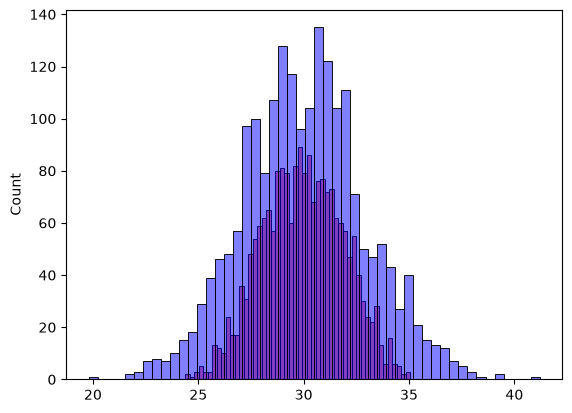

In [22]:
sns.histplot(y_val_pred_0, color='red', alpha=0.5, bins=50)
sns.histplot(y_val, color='blue', alpha=0.5, bins=50)

### Filling with mean

In [23]:
# Fill with mean
mean = df_train['horsepower'].mean()

X_train_mean = df_train.fillna(mean).values
w0, w = train_linear_regression(X_train_mean, y_train)

X_val_mean = df_val.fillna(mean).values
y_val_pred_mean = w0 + X_val_mean.dot(w)

In [24]:
y_val_pred_mean

array([31.54288381, 29.92505122, 31.56459523, ..., 30.54408311,
       30.85701236, 31.55313717], shape=(2000,))

In [25]:
round(rmse(y_val, y_val_pred_mean), 3)

np.float64(2.202)

<Axes: ylabel='Count'>

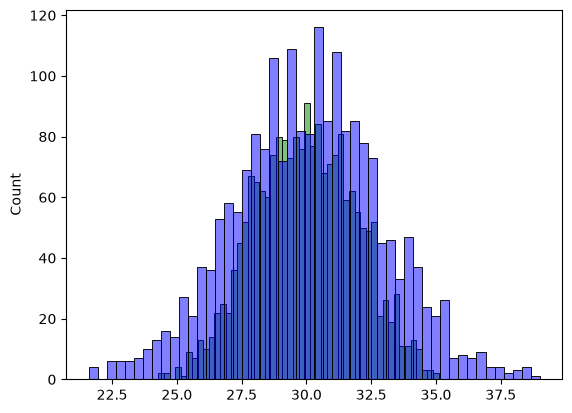

In [33]:
sns.histplot(y_val_pred_mean, color='green', alpha=0.5, bins=50)
sns.histplot(y_val, color='blue', alpha=0.5, bins=50)

Mean filling gives a better score!

### Question 4

* Now let's train a regularized linear regression.
* For this question, fill the NAs with 0. 
* Try different values of `r` from this list: `[0, 0.01, 0.1, 1, 5, 10, 100]`.
* Use RMSE to evaluate the model on the validation dataset.
* Round the RMSE scores to 4 decimal digits. This keeps the small but real
  regularization differences visible instead of turning several choices into a tie.
* Which `r` gives the best RMSE?

If multiple options give the same best RMSE, select the smallest `r`.

Options:

- 0
- 0.01
- 0.1
- 1
- 5
- 10
- 100


In [27]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

Now, let's train the model with different regularization values

In [28]:
scores = []

for r in [0.0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = df_train.fillna(0).values
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = df_val.fillna(0).values
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    scores.append(score)
    
    print(r, w0, round(score, 4))

0.0 -153.8849618825118 2.2053
0.01 -148.30921244106906 2.2058
0.1 -111.83871039289346 2.2241
1 -32.33186596496178 2.3492
5 -7.772852209996007 2.4094
10 -3.987116416016903 2.4195
100 -0.40821964884574036 2.4292


0.0 is the answer

### Question 5 

* We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
* Try different seed values: `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
* For each seed, do the train/validation/test split with 60%/20%/20% distribution.
* Fill the missing values with 0 and train a model without regularization.
* For each seed, evaluate the model on the validation dataset and collect the RMSE scores. 
* What's the standard deviation of all the scores? To compute the standard deviation, use `np.std`.
* Round the result to 3 decimal digits (`round(std, 3)`)

What's the value of std?

- 0.006
- 0.016
- 0.029
- 0.036

> Note: Standard deviation shows how different the values are.
> If it's low, then all values are approximately the same.
> If it's high, the values are different. 
> If standard deviation of scores is low, then our model is *stable*.

In [29]:
scores = []

for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:

    df_train, df_val, df_test = split_dataset(df, seed)

    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    
    X_train = df_train.drop(columns='fuel_efficiency_mpg').fillna(0).values
    w0, w = train_linear_regression(X_train, y_train)
    
    X_val = df_val.drop(columns='fuel_efficiency_mpg').fillna(0).values
    y_pred = w0 + X_val.dot(w)
    
    score = rmse(y_val, y_pred)
    
    scores.append(score)
    
    print(seed, w0, score)
    

0 -150.42885945111186 2.2392041430547938
1 -151.61231559499532 2.2021128210837784
2 -152.8406811265719 2.163419778753144
3 -152.33298096678598 2.204358876855315
4 -158.88856816531478 2.2018800943310333
5 -151.8573533887751 2.245785150908199
6 -154.37179137274728 2.2697212079518754
7 -155.0183525898363 2.1907945999366834
8 -150.43817400353458 2.2166112016961845
9 -154.3600748902909 2.2070365928196374


Seed 2 has the best score!

In [30]:
scores

[np.float64(2.2392041430547938),
 np.float64(2.2021128210837784),
 np.float64(2.163419778753144),
 np.float64(2.204358876855315),
 np.float64(2.2018800943310333),
 np.float64(2.245785150908199),
 np.float64(2.2697212079518754),
 np.float64(2.1907945999366834),
 np.float64(2.2166112016961845),
 np.float64(2.2070365928196374)]

In [31]:
round(np.std(scores), 3)

np.float64(0.029)



### Question 6

* Split the dataset like previously, use seed 9.
* Combine train and validation datasets.
* Fill the missing values with 0 and train a model with `r=0.001`. 
* What's the RMSE on the test dataset?

Options:

- 0.236
- 2.236
- 22.10
- 221.0

In [32]:
df_train, df_val, df_test = split_dataset(df, 9)

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)

X_full_train = df_full_train.drop(columns='fuel_efficiency_mpg').fillna(0).values
y_full_train = np.concatenate([y_train, y_val])

w0, w = train_linear_regression_reg(
    X_full_train,
    y_full_train,
    0.001
)

X_test = df_test.drop(columns='fuel_efficiency_mpg').fillna(0).values

y_pred = w0 + X_test.dot(w)

score = rmse(y_test, y_pred)

round(score, 3)

np.float64(2.236)



## Submit the results

* Submit your results here: https://courses.datatalks.club/ml-zoomcamp-2026/homework/hw02
* The numerical options are calculated from the pinned 2026 release. Use the value that matches your calculation; do not choose a merely close value.